1. select some of true positives in test set 
2. perturbing them by shuffling tokenized input
3. Inference original and shuffel input to the finetunned model and output prediction softmax value
6. Visualize attention score and Report changes

In [1]:
import os
import pandas as pd
import numpy as np
# from pyfaidx import Fasta

import torch
import transformers

import matplotlib.pyplot as plt

%matplotlib inline


/p/project1/hai_dnaori/piroozeh1/venv_dnabert2/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:

data_dir="data/OriDB_random_neg/train_dev_test_oridb"

data = pd.read_csv(os.path.join(data_dir,"test_window.tsv"), sep='\t', header=0)
print(data)

     chr    start      end                                                seq  \
0     13   363312   363811  ATGCATTACAAATTTGTATTTGATTCTATATATAGTTTCGTTATAT...   
1      4   483669   484168  TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...   
2      7  1056150  1056649  CCTTGTAGTTGTCCTGCAAAGATGGGTAGGTATTTTCCTTGATATG...   
3     15   766442   766941  CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...   
4      4   638559   639058  CTCTAACTAATACAAACTCCTTACTATCTAATATAACGGCTACATC...   
..   ...      ...      ...                                                ...   
125   10    18014    18513  AGTAAAACTCTTGTGTCTTTTCATCGAACGTCCATGCAGAACCACC...   
126   16   698214   698713  TAAGCTCTGAGGGGCTTAATACTGTTGGTAAGACTCCAGAAATCGT...   
127   16   339219   339718  CTGGACCGCCCGGTAAGTTCTGCTATTAACAAATTAAATAAAATTG...   
128    4  1252944  1253443  AGAGGTCATTGTTCAAAGTGAGTTGGTGAGTTTTGGTCGGATACCC...   
129    8   555958   556457  ACATAACTGAATGTTAAAATGGCATCATCAATACAGTATTACTGAT...   

     label  
0        0  
1

In [ ]:
pred_results  = np.load("/data/OriDB_random_neg/train_dev_test_oridb/DNABERT2/pred_results_test_model2.npy")
data['pred'] = pred_results
data['pred'] = data['pred'].apply(lambda x: 1 if x>0.5 else 0)
print(pred_results)

[0.00596435 0.99383545 0.00848924 0.9945714  0.00856034 0.00591839
 0.9946089  0.9946149  0.9944834  0.00599306 0.9945393  0.9926347
 0.9945397  0.9945517  0.99462044 0.9945884  0.99456906 0.00586831
 0.99453133 0.00584184 0.9941666  0.9945457  0.9945364  0.99451506
 0.00751891 0.02401546 0.9921163  0.9945427  0.99459165 0.9945971
 0.00588414 0.9943072  0.00585898 0.99458706 0.9945793  0.00605409
 0.00593577 0.994586   0.99459547 0.00590151 0.994557   0.99456257
 0.9945298  0.00644075 0.00626989 0.00599648 0.994494   0.994592
 0.9943626  0.00592392 0.00575113 0.0059236  0.00830391 0.9945741
 0.9944653  0.99455726 0.9945622  0.9945949  0.9933296  0.99314004
 0.00593962 0.9946163  0.9944711  0.00613169 0.9945779  0.00716066
 0.99452716 0.9944194  0.00582923 0.99454355 0.97786385 0.99454826
 0.00599439 0.9945585  0.9945109  0.01332614 0.99384874 0.99457294
 0.9945076  0.9945773  0.9941459  0.9945809  0.00617142 0.9940228
 0.9946038  0.00590487 0.99452966 0.911796   0.99452704 0.9945634
 0

In [4]:
true_positives = data[(data['label'] == 1) & (data['pred'] == 1)]

print(len(true_positives))

61


In [7]:
def inference_model( model_path, sequence):
    model_path = model_path
    config = transformers.BertConfig.from_pretrained(
                model_path,
                num_labels=2
        )
    config.output_attentions = True
    model = transformers.AutoModelForSequenceClassification.from_pretrained(model_path, config=config, from_tf=False,trust_remote_code=True)
    
    tokenizer = transformers.AutoTokenizer.from_pretrained(
        model_path,
        model_max_length=125,
        padding_side="right",
        use_fast=True,
        trust_remote_code=True
        
    )

   
    
   
    inputs = tokenizer(sequence, return_tensors="pt")
  
    input_ids = inputs['input_ids']
    
    output = model(input_ids)
   
    logits = output.logits
    pred=logits.detach().numpy()
  
    softmax = torch.nn.Softmax(dim=1)
    prob=softmax(torch.tensor(pred)).numpy()

    input_id_list = input_ids[0].tolist() # Batch index 0
    decoded_text = tokenizer.decode(input_id_list, skip_special_tokens=False)
    tokens = decoded_text.split()
    attention = output.attentions
    attention_scores=attention[-1].detach().numpy()
    avg_attention_scores = np.mean(attention_scores, axis=(1, 2))
    # print(avg_attention_scores)
    # print(avg_attention_scores.shape)
    flat_attention_scores = avg_attention_scores.flatten()
    bp_attention = []
    special_tokens = ["[CLS]", "[SEP]", "[PAD]"]
    for token, score in zip(tokens, flat_attention_scores):
        if token not in special_tokens:
        # For each base pair in the token, assign the same attention score
            for bp in token:
                bp_attention.append(score)



    

    #perturbing input by shuffling tokens, except CLS, SEP
    fixed_indices = (input_ids == 1) | (input_ids == 2)
    # print("fixed_indices ", fixed_indices.shape)
    # print("~fixed_indices", (~fixed_indices).shape)
    # fixed_positions = fixed_indices.nonzero(as_tuple=True)[0]

    # Extract tokens to shuffle (non-fixed)
    tokens_to_shuffle = input_ids[~fixed_indices]
    shuffled_indices=torch.randperm(tokens_to_shuffle.size(0))
    # Shuffle tokens
    # print(tokens_to_shuffle)
    shuffled_tokens = tokens_to_shuffle[shuffled_indices]
    # print(shuffled_tokens)
    # Recover original positions from shuffled indices
    inverse_indices = torch.argsort(shuffled_indices)
    # Create shuffled output
    shuffled_input_ids = input_ids.clone()
    shuffled_input_ids[~fixed_indices] = shuffled_tokens
    output2 = model(shuffled_input_ids)
   
    logits2 = output2.logits
    pred2=logits2.detach().numpy()
  
    softmax = torch.nn.Softmax(dim=1)
    prob2=softmax(torch.tensor(pred2)).numpy()
    # 

    # input_id_list2 = shuffled_input_ids[0].tolist() # Batch index 0
    # decoded_text = tokenizer.decode(input_id_list2, skip_special_tokens=False)
    # tokens2 = decoded_text.split()
    attention2 = output2.attentions
    attention_scores2=attention2[-1].detach().numpy()
    avg_attention_scores2 = np.mean(attention_scores2, axis=(1, 2))
    # print("shuffles_atttention",avg_attention_scores2)
    # print(avg_attention_scores2.shape)
    # print("input_ids",input_ids)
    # print("shuffled_input_ids ",shuffled_input_ids)
    # print(shuffled_input_ids.shape)
    
    # print(inverse_indices)
    # print("inverse_indices",inverse_indices.shape)
   
    flat_attention_scores2 = avg_attention_scores2.flatten()
    # print(flat_attention_scores2.shape)
    restored_attention_scores2 = np.zeros_like(flat_attention_scores2)
    
    

    restored_attention_scores2[0] = flat_attention_scores2[0]  # Keep CLS fixed
    restored_attention_scores2[-1] = flat_attention_scores2[-1]  # Keep SEP fixed
    inverse_indices1=inverse_indices+1
    # print("inverse_indices",inverse_indices1)
    restored_attention_scores2[1:-1] = flat_attention_scores2[0:-1][inverse_indices1.cpu().numpy()]
    # print("restored_attention_scores2",restored_attention_scores2)
    # print(restored_attention_scores2.shape)

    bp_attention2 = []

    for token, score in zip(tokens, restored_attention_scores2):
        if token not in special_tokens:
        # For each base pair in the token, assign the same attention score
            for bp in token:
                bp_attention2.append(score)
    

        
    
    return prob, prob2, bp_attention, bp_attention2

    

In [8]:
def visualize(atten1, atten2, original_e, original_s, start):
   
    
    x = range(len(atten1))
    e=int(original_e - start)
    s=int(original_s - start)
    plt.figure(figsize=(12, 4))
    plt.plot(x, atten1, label='Attention Seq',linestyle='-', marker='o', markersize=2)
    plt.plot(x, atten2, label='Attention shuffled seq',linestyle='-', marker='s', markersize=2)
    
    plt.axvline(x=s, color='red', linestyle='--', label='origin')
    plt.axvline(x=e, color='red', linestyle='--')



    # Add labels, title, and legend
    plt.title("Attention Scores Comparison")
    plt.xlabel("Position")
    plt.ylabel("Attention Score")
    plt.legend()
    plt.grid(True)
    plt.show()

/p/software/juwelsbooster/stages/2024/software/PyTorch/2.1.2-gcccoreflexiblas-12.3.0-3.3.1/lib/python3.11/site-packages/torch/cuda/__init__.py:611: UserWarning: Can't initialize NVML
  warnings.warn("Can't initialize NVML")
/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      4
start                                               483669
end                                                 484168
seq      TTGATTTATACCATTTTGAAATCTAATCTTGCTCCAAGGGAGAAGC...
label                                                    1
pred                                                     1
Name: 1, dtype: object
    chr   start     end        name  length
53    4  483846  484091  417,00 ARS     246
original:  0.99383545
shuffled:  0.994468


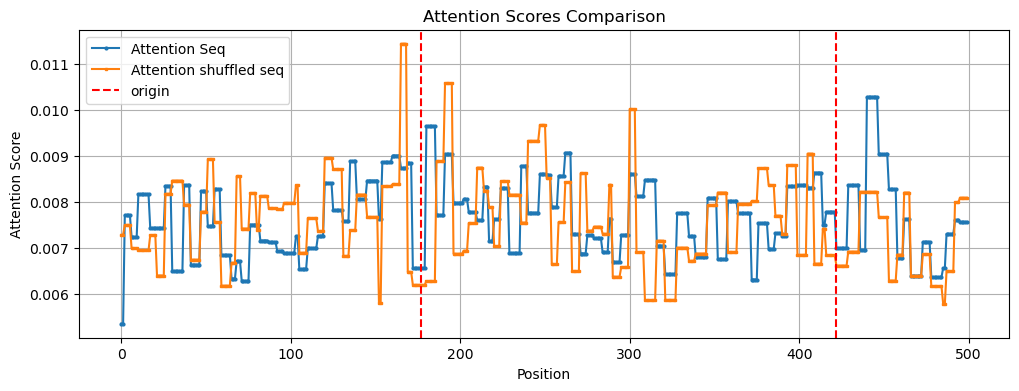

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     15
start                                               766442
end                                                 766941
seq      CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...
label                                                    1
pred                                                     1
Name: 3, dtype: object
     chr   start     end         name  length
297   15  766617  766862  1523,00 ARS     246
original:  0.9945714
shuffled:  0.9945707


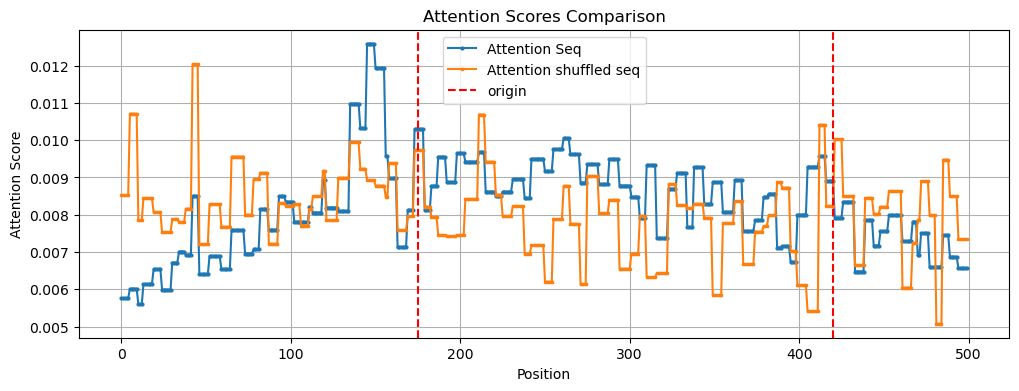

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     15
start                                               337119
end                                                 337618
seq      AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...
label                                                    1
pred                                                     1
Name: 6, dtype: object
     chr   start     end         name  length
287   15  337279  337528  1513,00 ARS     250
original:  0.9946089
shuffled:  0.994547


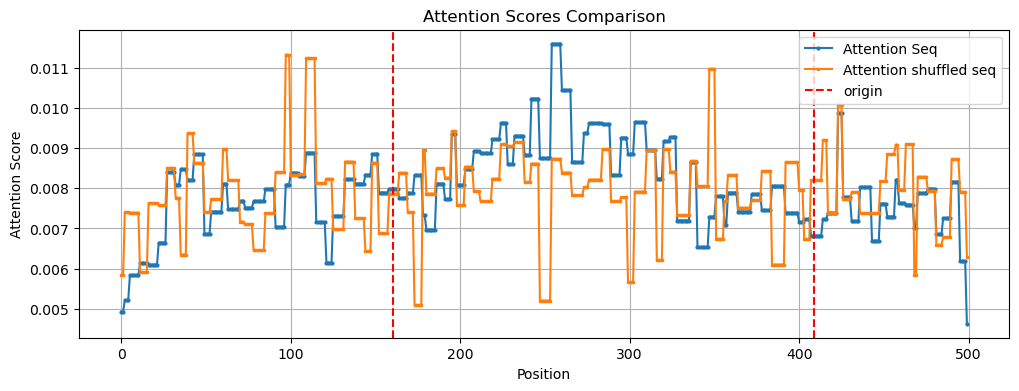

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      7
start                                               607176
end                                                 607675
seq      AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...
label                                                    1
pred                                                     1
Name: 7, dtype: object
     chr   start     end      name  length
123    7  607176  607619  ARS724.5     444
original:  0.9946149
shuffled:  0.9945229


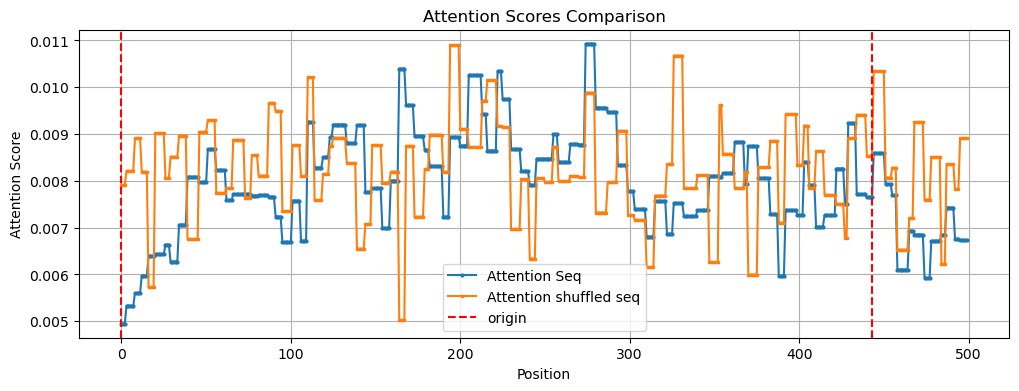

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      6
start                                               256090
end                                                 256589
seq      GCATGGAAGATATTCCGGGGTTGTTTAACAATAAACGTGTAGAGTA...
label                                                    1
pred                                                     1
Name: 12, dtype: object
     chr   start     end        name  length
105    6  256263  256418  609,00 ARS     156
original:  0.9945397
shuffled:  0.9943462


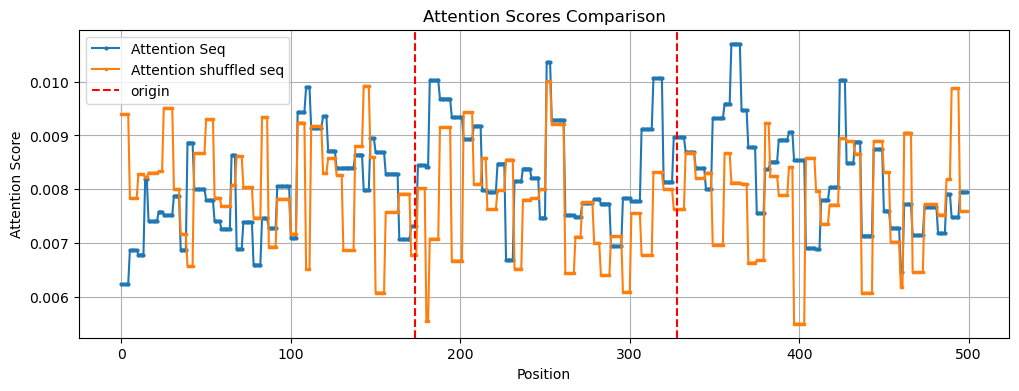

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      2
start                                               622494
end                                                 622993
seq      AGCCAAACTGAAAATTTCCGTTCACGATATTTGAATCTAGTGTTAG...
label                                                    1
pred                                                     1
Name: 14, dtype: object
    chr   start     end        name  length
19    2  622625  622894  220,00 ARS     270
original:  0.99462044
shuffled:  0.9945128


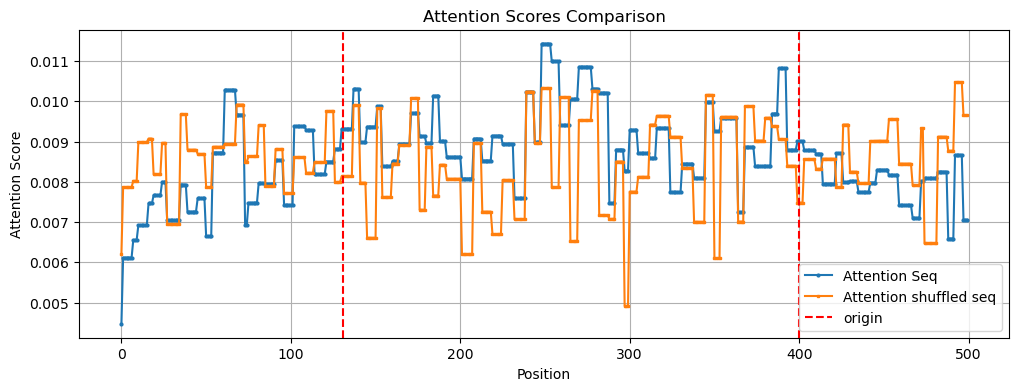

In [ ]:
model_path = "/data/OriDB_random_neg/train_dev_test_oridb/DNABERT2/model2"
original_origin=pd.read_csv("data/yeast_oridbLess500.csv")   
for index, row in true_positives.iterrows():
    if index<15:
    
            prob1, prob2, att1, att2=inference_model( model_path, row["seq"])
        # if prob2[0,1] < prob1[0,1]:
            matching_rows = original_origin[(original_origin['chr'] == row['chr']) & (original_origin['start'] >= row['start']) & (original_origin['end'] <= row['end'])]
            print(row)
            print(matching_rows)
            
            origin_start=matching_rows['start'].values[0]
            origin_end=matching_rows['end'].values[0]
            print("original: ", prob1[0,1])
            
            print("shuffled: ", prob2[0,1])
           
            visualize(att1, att2, origin_start, origin_end, row['start']) 
        


/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     15
start                                               766442
end                                                 766941
seq      CAGTTTACAAGAATCACAACAAAAGGCGCCTTTGCAGAGGCCCCTT...
label                                                    1
pred                                                     1
Name: 3, dtype: object
     chr   start     end         name  length
297   15  766617  766862  1523,00 ARS     246
original:  0.9945714
shuffled:  0.99455243


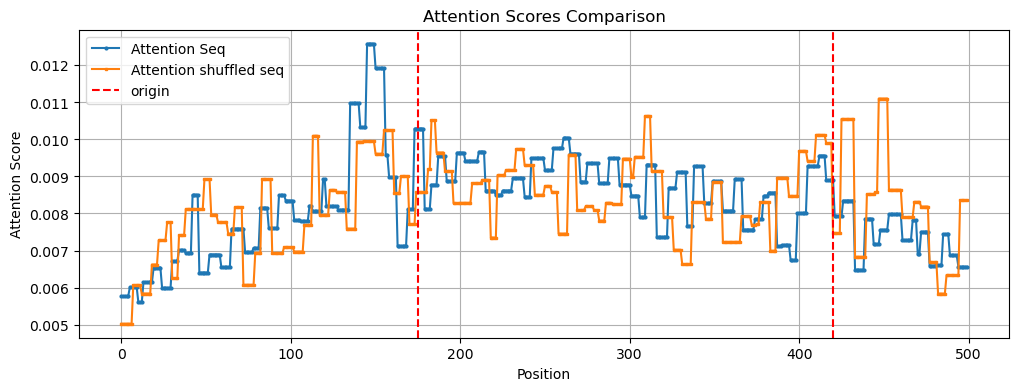

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     15
start                                               337119
end                                                 337618
seq      AAGAACCAGTGCAGGATATATATTATTTCCCACGGTTTTTCTCCAC...
label                                                    1
pred                                                     1
Name: 6, dtype: object
     chr   start     end         name  length
287   15  337279  337528  1513,00 ARS     250
original:  0.9946089
shuffled:  0.994476


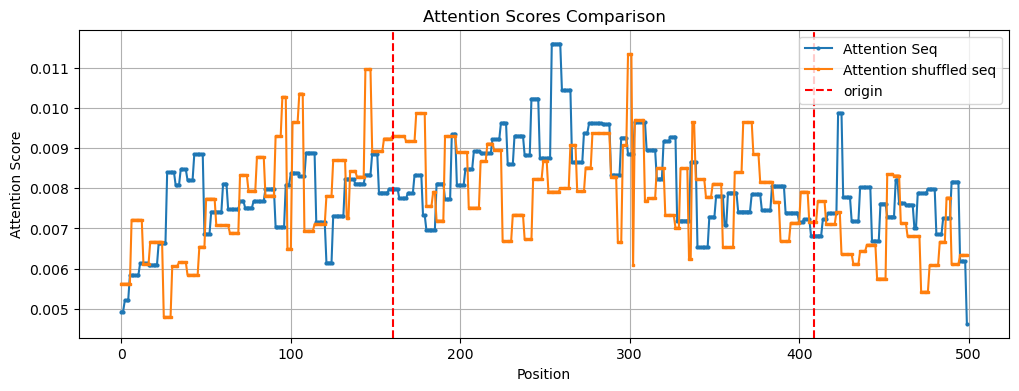

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      7
start                                               607176
end                                                 607675
seq      AAATAGAAGAGGTAAACCAATCAATGGCCCGTTAGTTTGCCATTTG...
label                                                    1
pred                                                     1
Name: 7, dtype: object
     chr   start     end      name  length
123    7  607176  607619  ARS724.5     444
original:  0.9946149
shuffled:  0.9945478


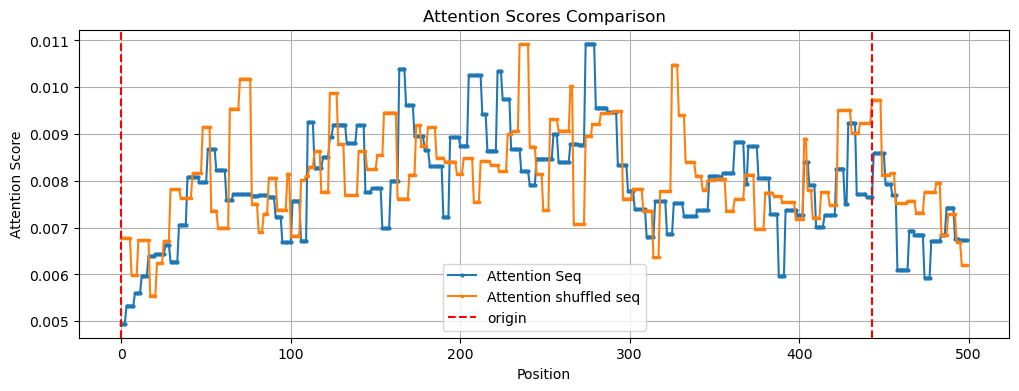

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      2
start                                               622494
end                                                 622993
seq      AGCCAAACTGAAAATTTCCGTTCACGATATTTGAATCTAGTGTTAG...
label                                                    1
pred                                                     1
Name: 14, dtype: object
    chr   start     end        name  length
19    2  622625  622894  220,00 ARS     270
original:  0.99462044
shuffled:  0.9945562


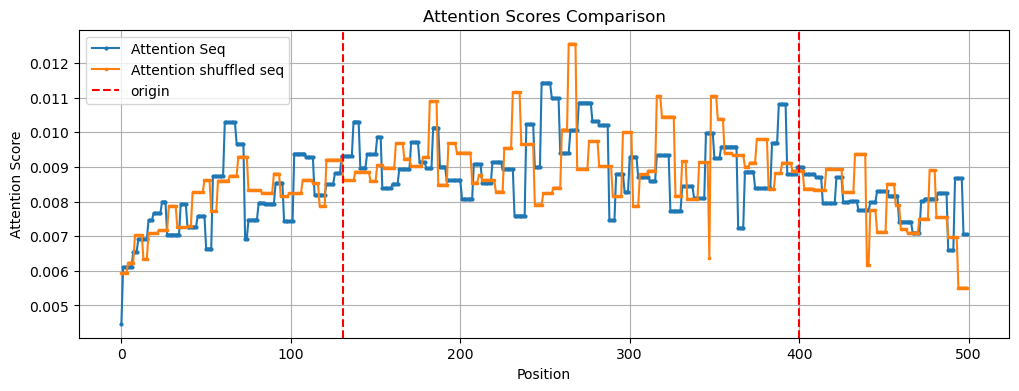

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     14
start                                               412206
end                                                 412705
seq      AGGAATAGATTAAAGAACACTATATATGCATAGCCACTTCAAAACG...
label                                                    1
pred                                                     1
Name: 15, dtype: object
     chr   start     end         name  length
268   14  412263  412493  1417,00 ARS     231
original:  0.9945884
shuffled:  0.9944846


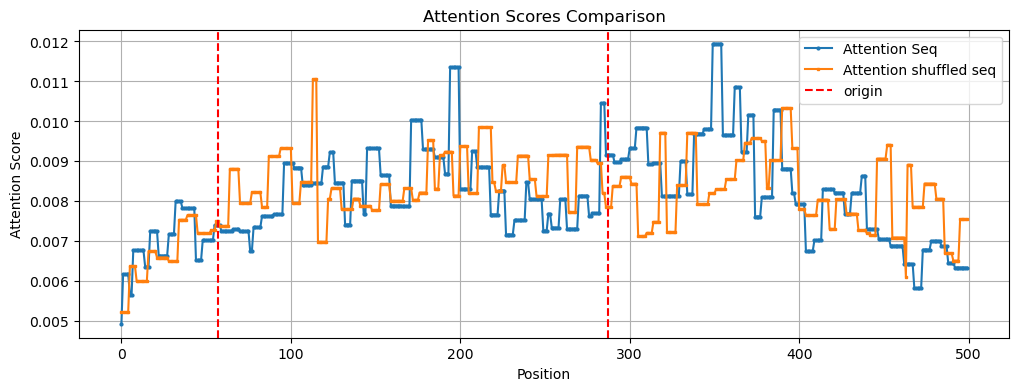

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      7
start                                               231509
end                                                 232008
seq      TGTTCATTAATTTTTATGAACTTGACTTCATCCTACTTGGATTACA...
label                                                    1
pred                                                     1
Name: 20, dtype: object
     chr   start     end        name  length
113    7  231909  231984  711,00 ARS      76
original:  0.9941666
shuffled:  0.99333376


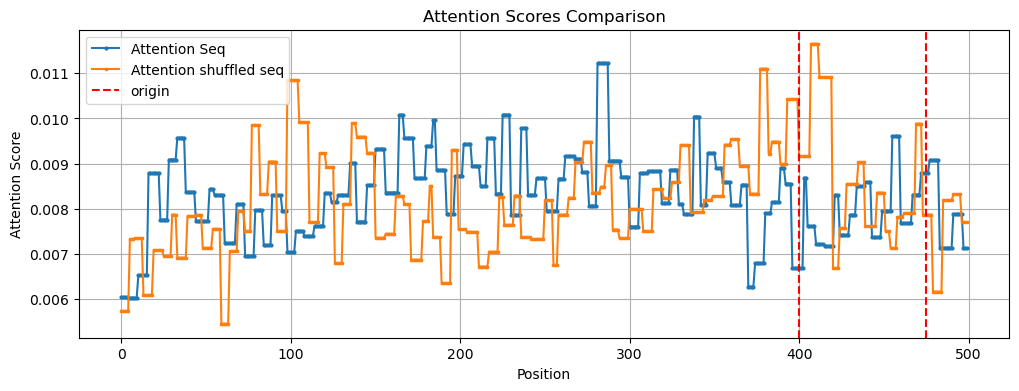

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     14
start                                               560913
end                                                 561412
seq      AGAGTAATCGCAAACTATATTGAAGTTGGCAAAGGCACATGATCCA...
label                                                    1
pred                                                     1
Name: 22, dtype: object
     chr   start     end         name  length
272   14  561106  561384  1422,00 ARS     279
original:  0.9945364
shuffled:  0.9944812


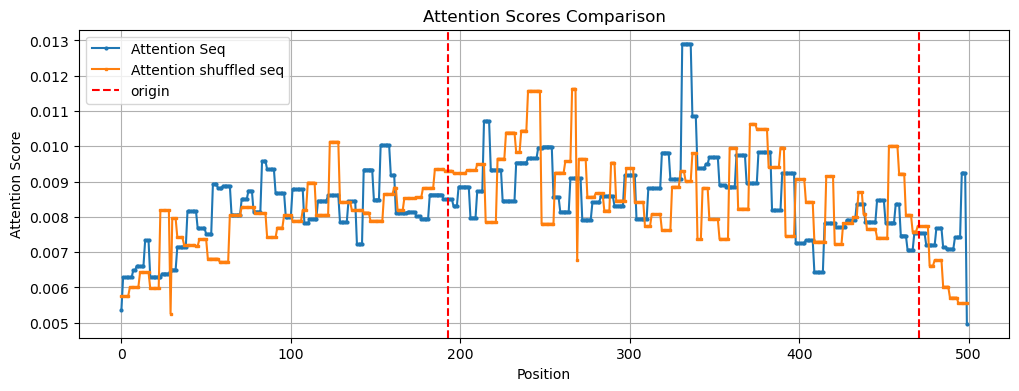

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     13
start                                               554359
end                                                 554858
seq      CCATAGACGGAAGCATTAAGGATATTAAGTGATCAAAGATACTAGA...
label                                                    1
pred                                                     1
Name: 23, dtype: object
     chr   start     end         name  length
246   13  554392  554750  1322,00 ARS     359
original:  0.99451506
shuffled:  0.99450195


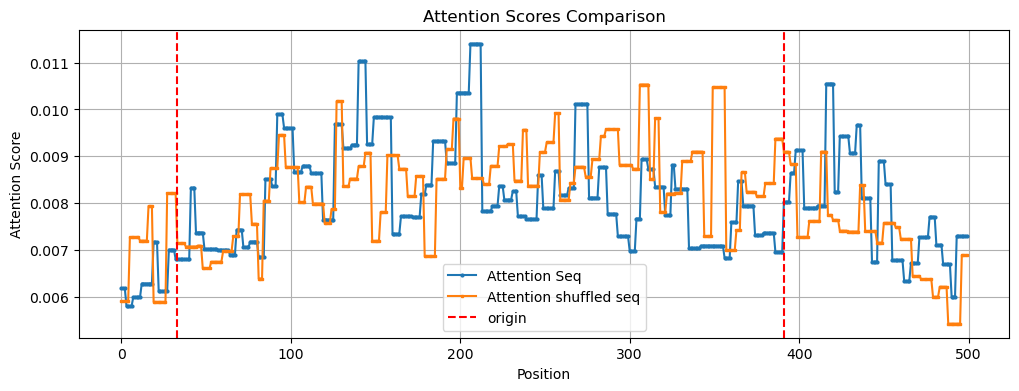

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     16
start                                                73009
end                                                  73508
seq      AGTACACTGGTCAGGAAATGGTGCTTTTGCGAGGAGAATGTGTGTG...
label                                                    1
pred                                                     1
Name: 27, dtype: object
     chr  start    end         name  length
305   16  73038  73283  1605,00 ARS     246
original:  0.99454284
shuffled:  0.99450123


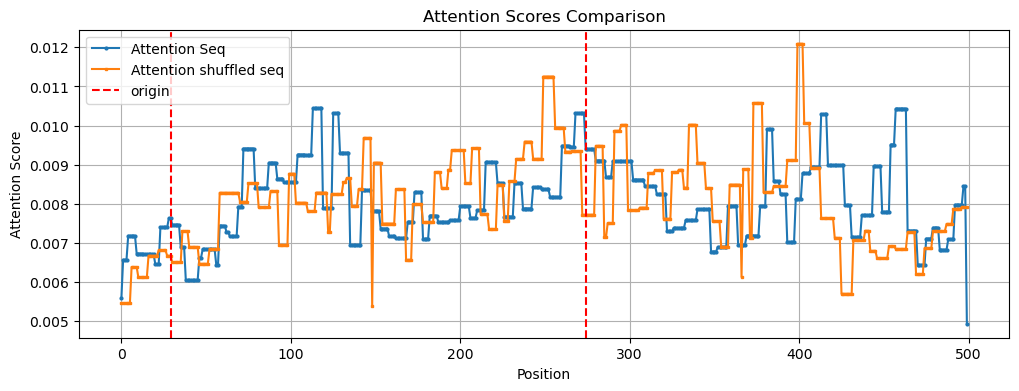

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      4
start                                               748222
end                                                 748721
seq      AGACGAAATAAGAAGTACAAGAAAATGGAATCCCTCTCAAAATTAT...
label                                                    1
pred                                                     1
Name: 28, dtype: object
    chr   start     end      name  length
59    4  748384  748630  ARS422.5     247
original:  0.99459165
shuffled:  0.99458534


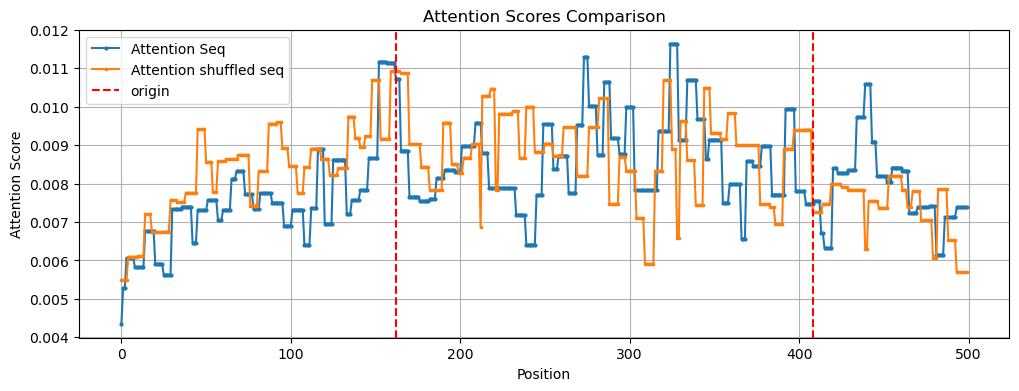

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      7
start                                               484766
end                                                 485265
seq      TCCATAGTTGTTTTATCTTATTCTTGGCATTGATCTGCTTATTAAA...
label                                                    1
pred                                                     1
Name: 29, dtype: object
     chr   start     end        name  length
119    7  484932  485160  719,00 ARS     229
original:  0.9945971
shuffled:  0.99455607


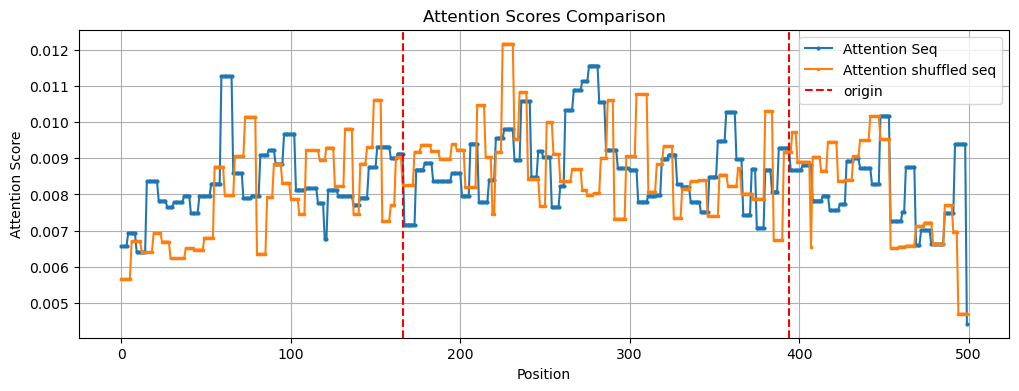

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      4
start                                               462286
end                                                 462785
seq      GGTGGGACAGGTGAACTTTTGGATTGGAACTCGATTTCTGACTGGG...
label                                                    1
pred                                                     1
Name: 31, dtype: object
    chr   start     end        name  length
52    4  462430  462700  416,00 ARS     271
original:  0.9943072
shuffled:  0.99050975


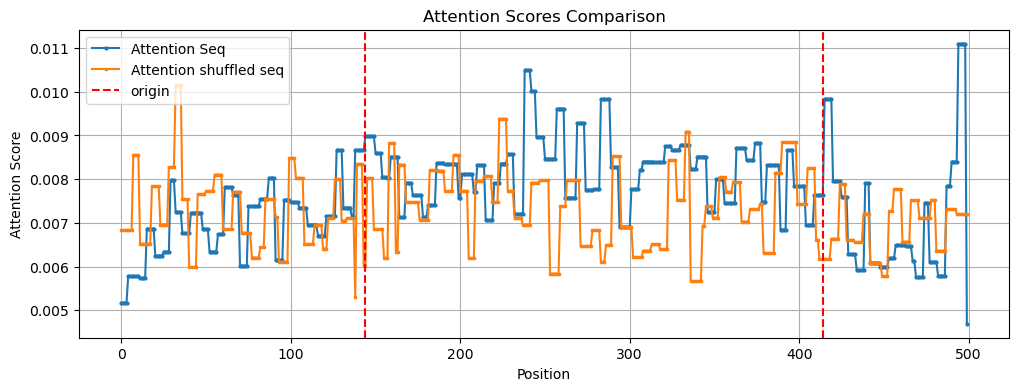

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      4
start                                               407982
end                                                 408481
seq      GAGGACTTTTCAGTTTGAATTTGAGATATGTTGTGGAAGTTTCCCA...
label                                                    1
pred                                                     1
Name: 33, dtype: object
    chr   start     end        name  length
50    4  408070  408312  414,00 ARS     243
original:  0.99458706
shuffled:  0.9945134


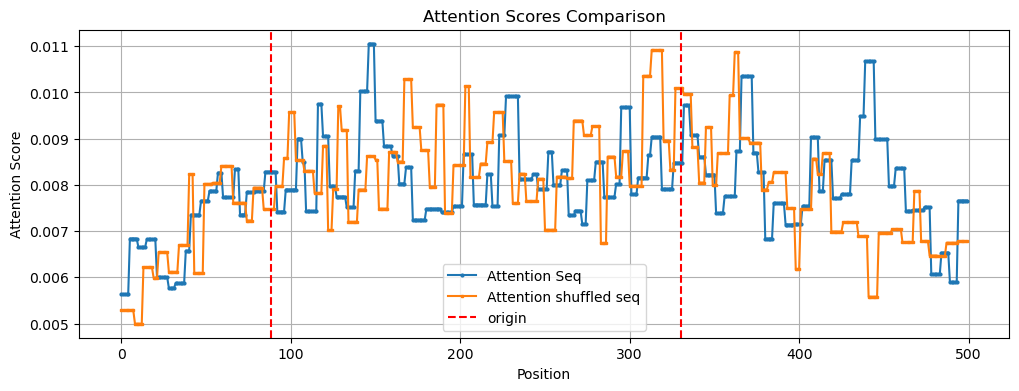

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      4
start                                               235710
end                                                 236209
seq      GAAAATAGGCCAATACCGACAATTAAGCCTTTTAATTTTAGTAAAG...
label                                                    1
pred                                                     1
Name: 37, dtype: object
    chr   start     end      name  length
46    4  235935  236184  ARS409.5     250
original:  0.994586
shuffled:  0.99454206


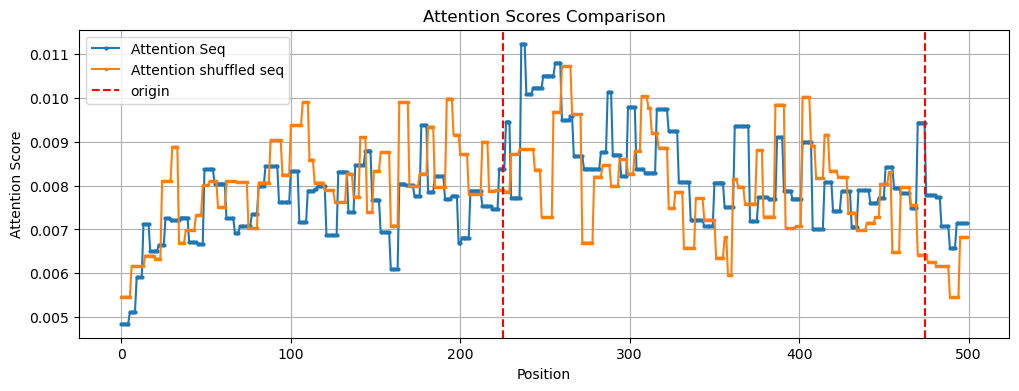

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     14
start                                               126488
end                                                 126987
seq      GCGTTCTTTGGAAGCGAGTGCAGCCGATGAAAGCGATGAAGATGAA...
label                                                    1
pred                                                     1
Name: 38, dtype: object
     chr   start     end         name  length
261   14  126488  126981  1410,00 ARS     494
original:  0.99459547
shuffled:  0.99454486


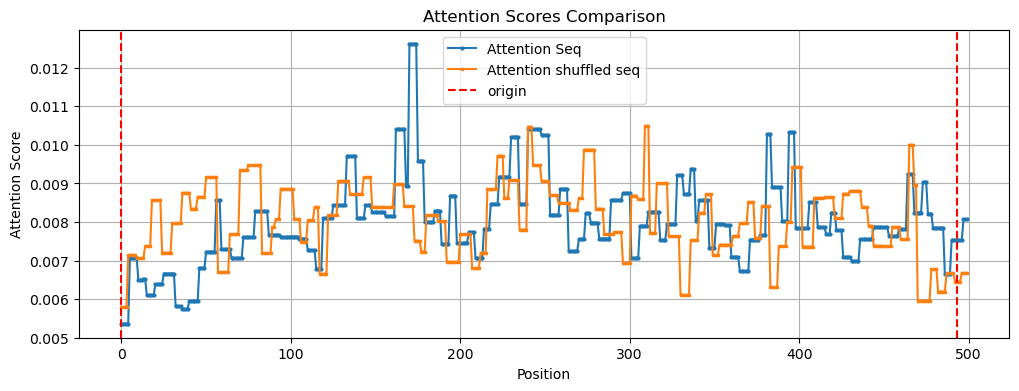

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      7
start                                               715109
end                                                 715608
seq      TTTCTTCTTATCTCAAAATGAAATTACCGTTTGCAATCAACACCGG...
label                                                    1
pred                                                     1
Name: 40, dtype: object
     chr   start     end        name  length
126    7  715273  715556  728,00 ARS     284
original:  0.994557
shuffled:  0.994522


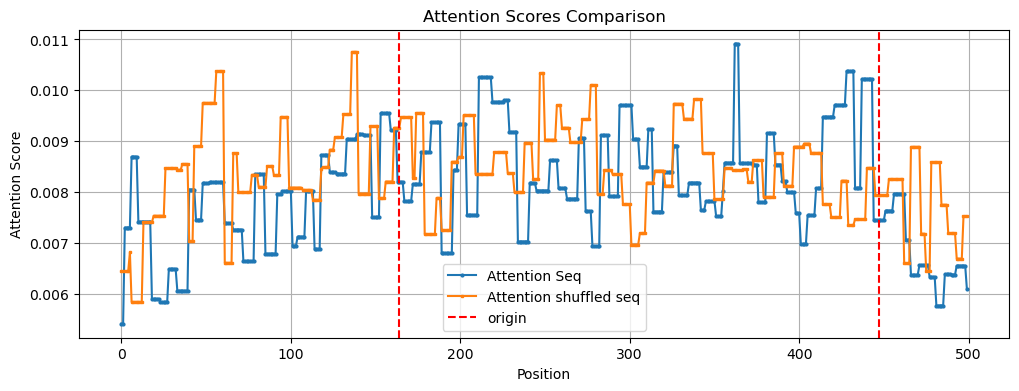

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      8
start                                               447524
end                                                 448023
seq      GTCAGTCATAAAGCAGGAGGTCGAACGACTAGGCAACGATGTTTTT...
label                                                    1
pred                                                     1
Name: 42, dtype: object
     chr   start     end        name  length
146    8  447619  447853  820,00 ARS     235
original:  0.9945298
shuffled:  0.9944296


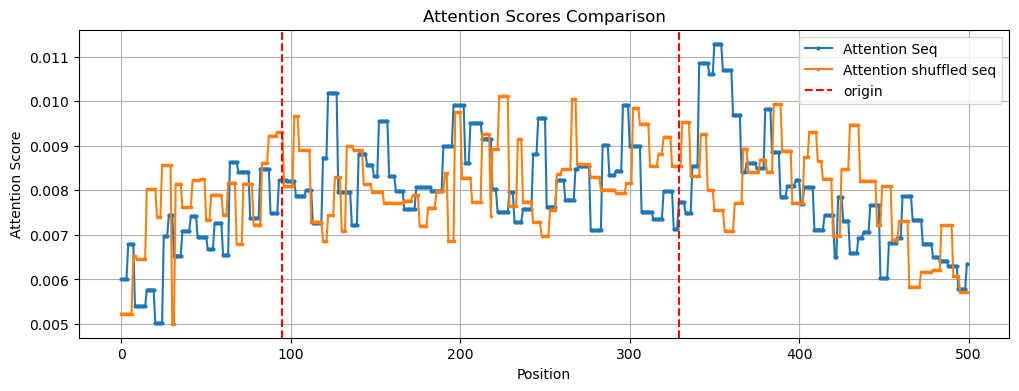

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     16
start                                               695396
end                                                 695895
seq      AAAATGTCTCAATGCAGCTTTGGCTGCTGCGGAACTTATCCGCTTT...
label                                                    1
pred                                                     1
Name: 47, dtype: object
     chr   start     end         name  length
318   16  695432  695681  1625,00 ARS     250
original:  0.994592
shuffled:  0.9944993


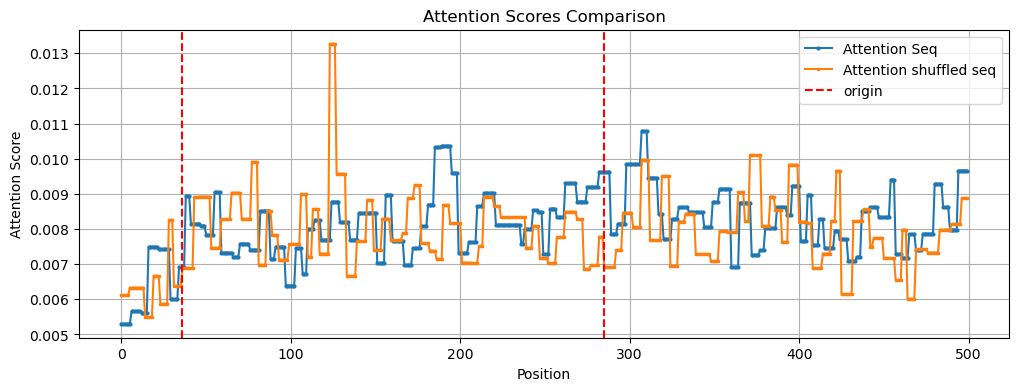

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     10
start                                                99300
end                                                  99799
seq      TACTACTGGAATTTGTCCAAGAACATTTATAGGTTTGTTGGCTCTA...
label                                                    1
pred                                                     1
Name: 53, dtype: object
     chr  start    end         name  length
169   10  99359  99796  1006,00 ARS     438
original:  0.9945741
shuffled:  0.99456054


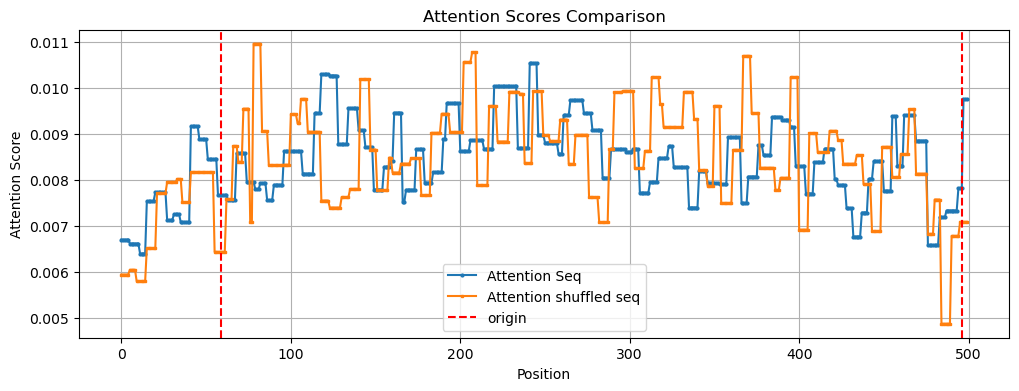

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     14
start                                               195801
end                                                 196300
seq      CAGATCAGCCCCTCGACCTGCCCACGGGTTTGAAGGAGGCGTATAG...
label                                                    1
pred                                                     1
Name: 54, dtype: object
     chr   start     end         name  length
263   14  196055  196291  1412,00 ARS     237
original:  0.9944653
shuffled:  0.9944371


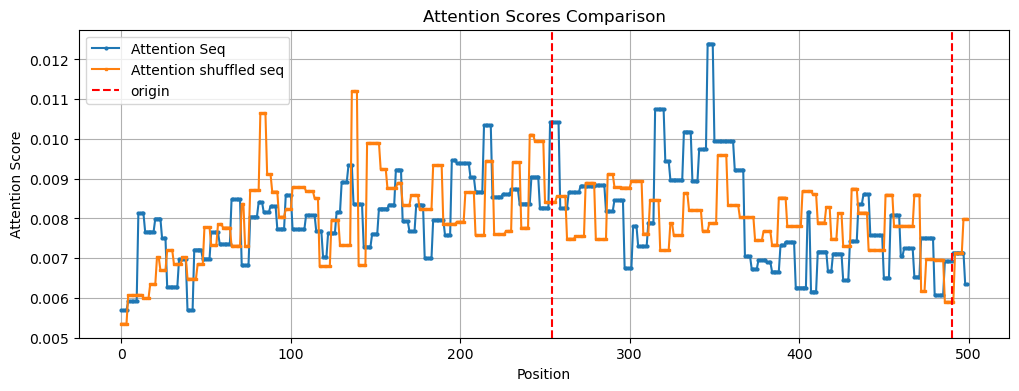

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     15
start                                               783090
end                                                 783589
seq      ACATGAATGAAAATACATCAAATGATGTAGAGAAAGCAAGTGAAGA...
label                                                    1
pred                                                     1
Name: 56, dtype: object
     chr   start     end         name  length
298   15  783344  783563  1524,00 ARS     220
original:  0.9945622
shuffled:  0.9945268


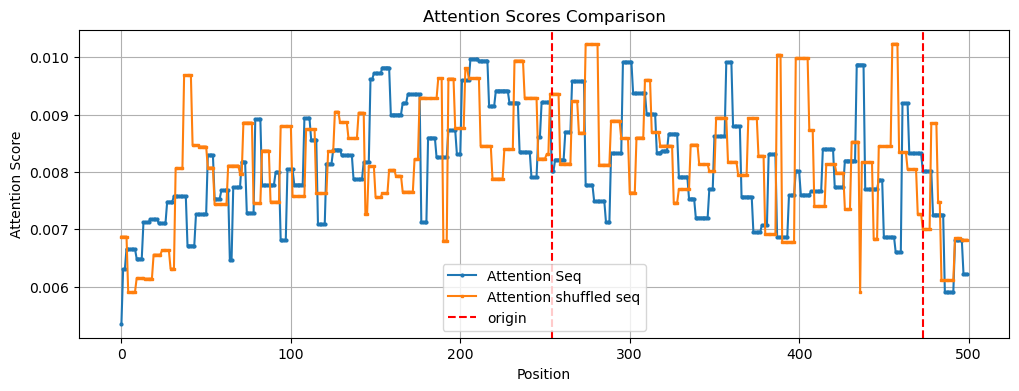

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      8
start                                               245498
end                                                 245997
seq      TACATAACTGGACCGAAGAGTTATTGGGAAAGAAGAAAGAAGCATG...
label                                                    1
pred                                                     1
Name: 57, dtype: object
     chr   start     end        name  length
142    8  245719  245968  813,00 ARS     250
original:  0.9945949
shuffled:  0.9944787


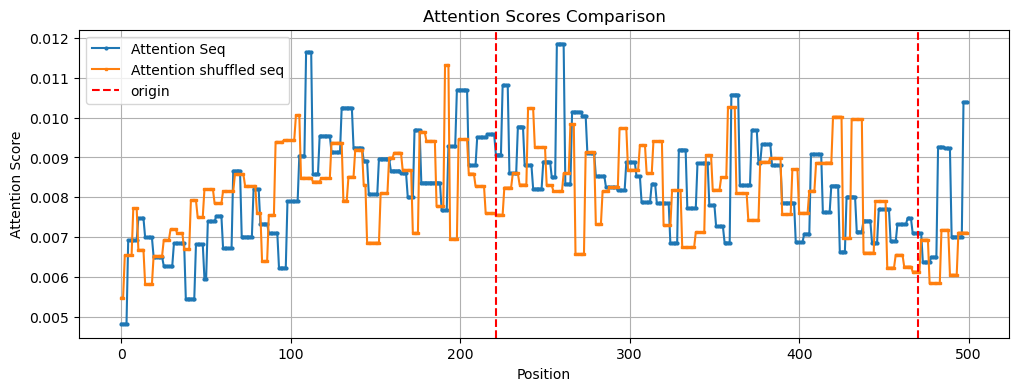

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     15
start                                               729732
end                                                 730231
seq      ATATATCATTGTGCTCACATGTGCTAACATGTGAGCACTCCAAGCT...
label                                                    1
pred                                                     1
Name: 61, dtype: object
     chr   start     end         name  length
296   15  729739  729969  1521,00 ARS     231
original:  0.9946163
shuffled:  0.994565


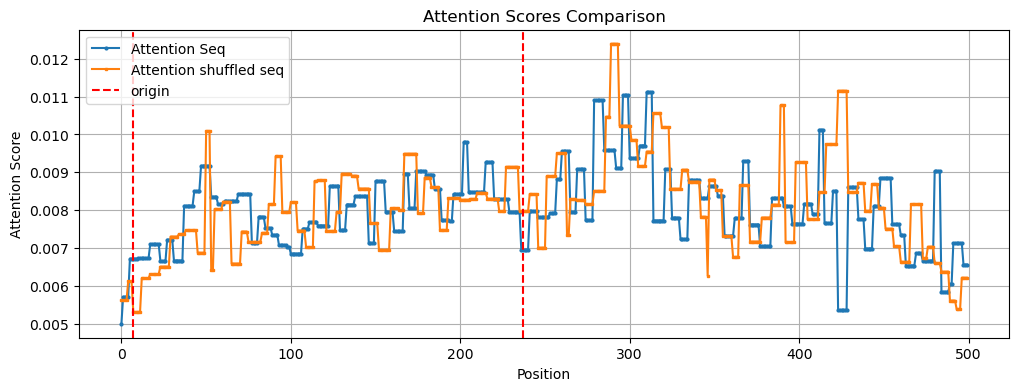

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      9
start                                                73778
end                                                  74277
seq      TTAAGTACATGAAGGTAGAATATTTCAAATATGATGTCAAAGGCGA...
label                                                    1
pred                                                     1
Name: 66, dtype: object
     chr  start    end        name  length
152    9  73803  74220  907,00 ARS     418
original:  0.99452716
shuffled:  0.9945081


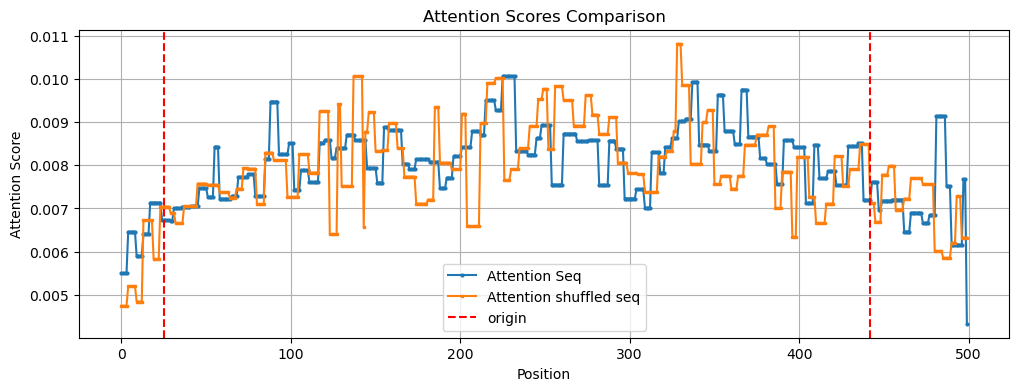

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      7
start                                               653594
end                                                 654093
seq      TAACTGACTCAGGCGTTTCCTTCATTGAAATGCTCATCTATTGCCA...
label                                                    1
pred                                                     1
Name: 69, dtype: object
     chr   start     end        name  length
124    7  653611  654091  726,00 ARS     481
original:  0.99454355
shuffled:  0.99450845


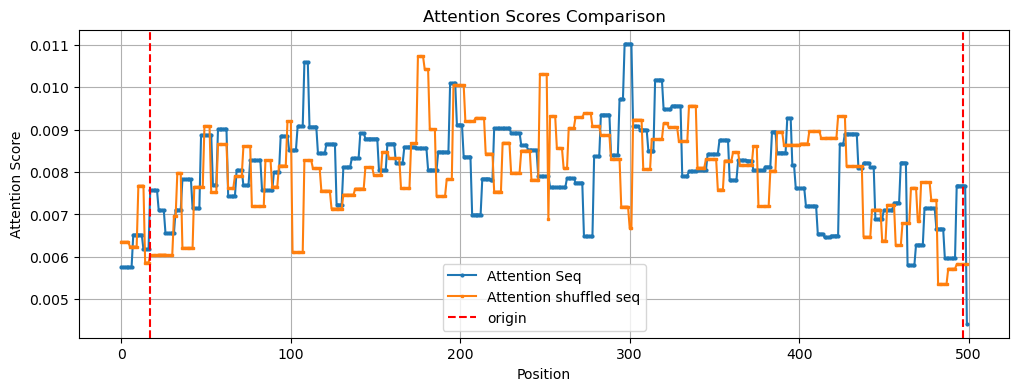

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      7
start                                                64222
end                                                  64721
seq      GGTTTTGTTTTGCCTGGTTTGGGCCTGACTTTAGTTATATGATTAT...
label                                                    1
pred                                                     1
Name: 71, dtype: object
     chr  start    end        name  length
107    7  64279  64528  702,00 ARS     250
original:  0.99454826
shuffled:  0.9945216


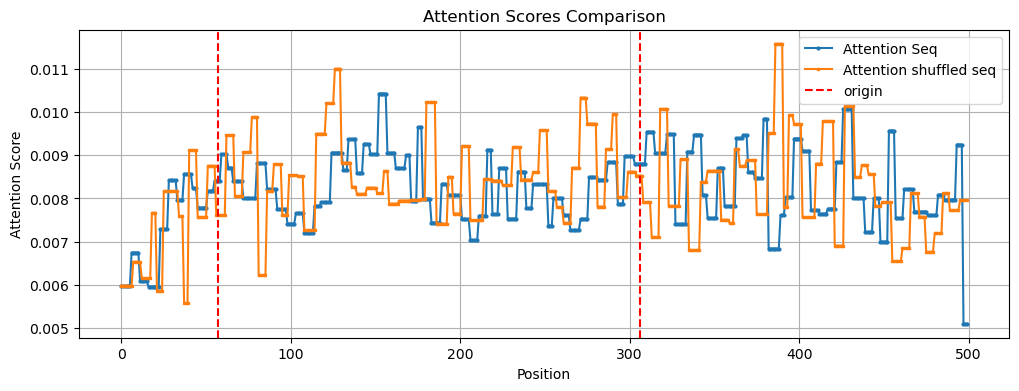

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     12
start                                              1007053
end                                                1007552
seq      AAGAAATAGCAACAAAATTAGATAAATCTCGGTGGAGTTATCCAAA...
label                                                    1
pred                                                     1
Name: 73, dtype: object
     chr    start      end         name  length
228   12  1007180  1007470  1232,00 ARS     291
original:  0.9945585
shuffled:  0.9944747


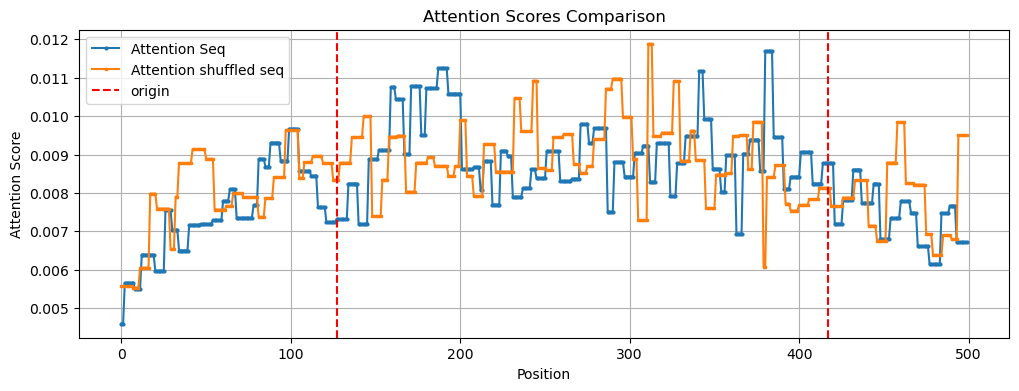

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     10
start                                               416879
end                                                 417378
seq      CCAATAAATAATAAAATCCTTTACTAATACTAATATAAGGATTTCT...
label                                                    1
pred                                                     1
Name: 77, dtype: object
     chr   start     end         name  length
175   10  416888  417134  1014,00 ARS     247
original:  0.99457294
shuffled:  0.9945042


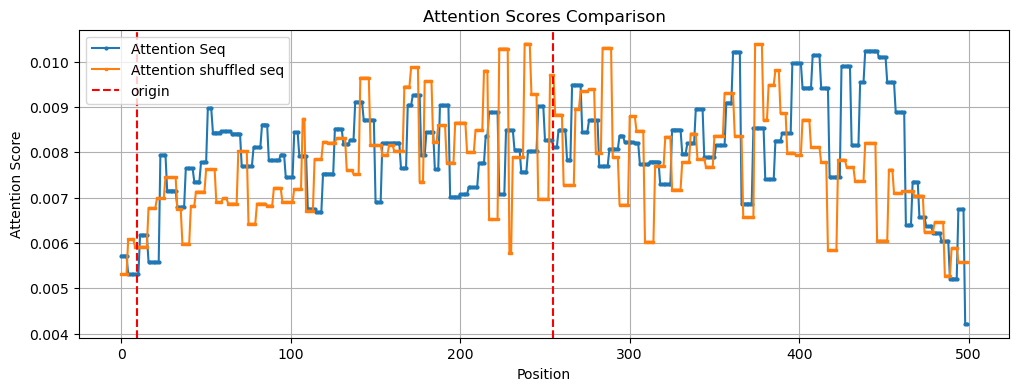

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      4
start                                               913724
end                                                 914223
seq      AGCTGACGATCCAGTCAGCGACATCTGTCTTTTTTTAATTACTATT...
label                                                    1
pred                                                     1
Name: 79, dtype: object
    chr   start     end        name  length
62    4  913780  914029  428,00 ARS     250
original:  0.9945773
shuffled:  0.9945614


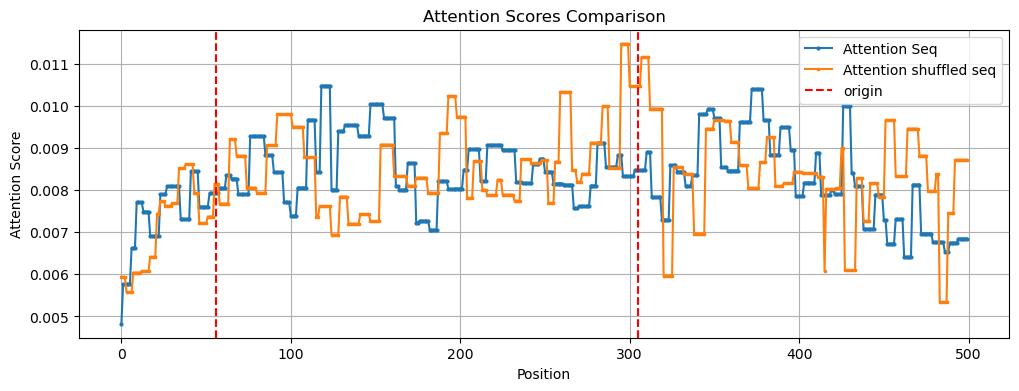

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      3
start                                               224719
end                                                 225218
seq      ATACGACCGGTCCTGAGAAAAGAGAAAGGGAACACTTCTAATTTAT...
label                                                    1
pred                                                     1
Name: 81, dtype: object
    chr   start     end        name  length
35    3  224807  225053  315,00 ARS     247
original:  0.9945809
shuffled:  0.994511


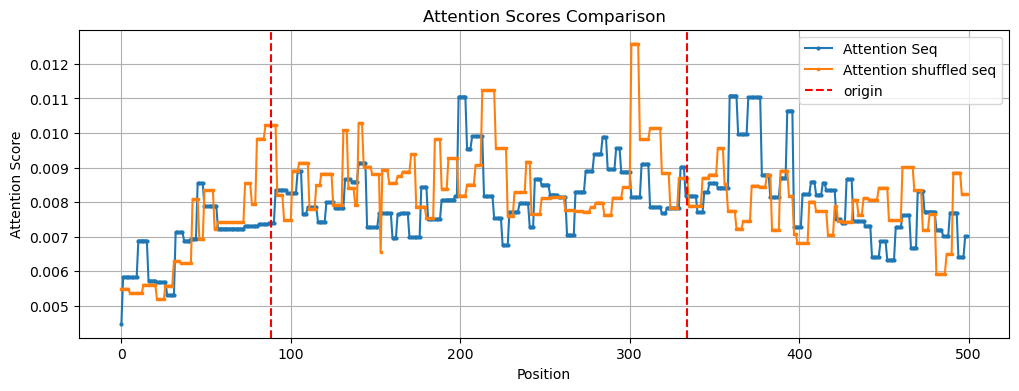

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      8
start                                               391984
end                                                 392483
seq      TGTAGGTAAAAATCTTTGATTTATCTTATCTGGTTGCAATGCTTCT...
label                                                    1
pred                                                     1
Name: 84, dtype: object
     chr   start     end        name  length
144    8  392148  392391  818,00 ARS     244
original:  0.9946038
shuffled:  0.9945709


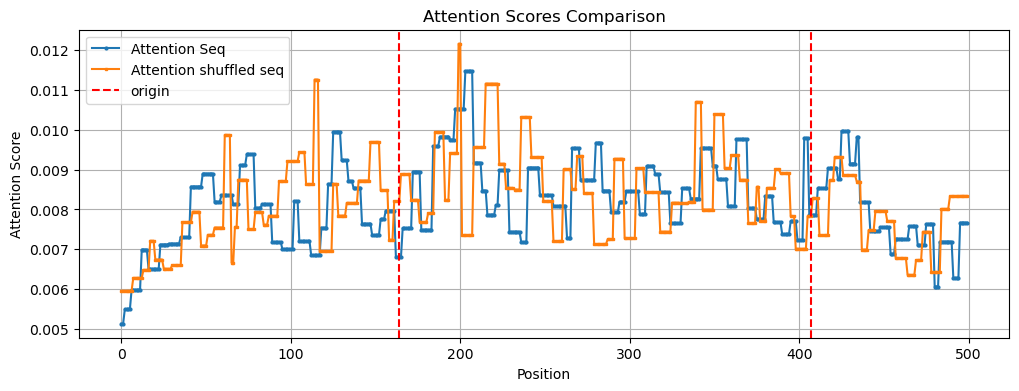

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      8
start                                               168323
end                                                 168822
seq      GCAAATGGCAATTCACTTCTTGGAGTAAAGATCCTCAACTTGTAAT...
label                                                    1
pred                                                     1
Name: 89, dtype: object
     chr   start     end        name  length
141    8  168531  168773  809,00 ARS     243
original:  0.9945634
shuffled:  0.99454343


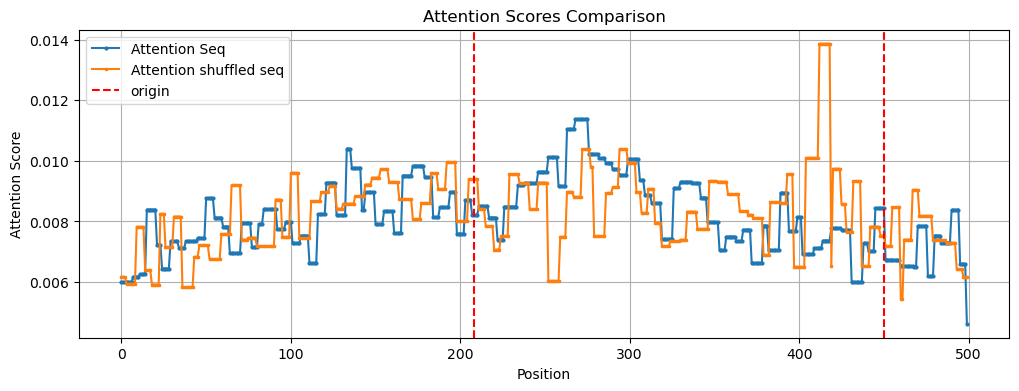

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     12
start                                               450454
end                                                 450953
seq      ATTAGTTTGCCAGGATATACCTTATCCAATTTAGCGTGACGATCTT...
label                                                    1
pred                                                     1
Name: 92, dtype: object
     chr   start     end         name  length
214   12  450485  450726  1216,00 ARS     242
original:  0.9946003
shuffled:  0.9944798


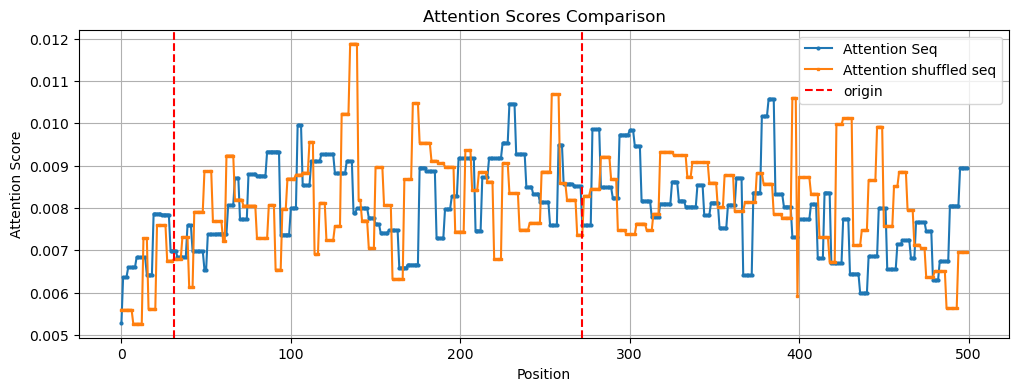

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      5
start                                               406620
end                                                 407119
seq      TCCTTTATCAAAAGACTACACGCACATATATATTAATCCCGGTATG...
label                                                    1
pred                                                     1
Name: 94, dtype: object
    chr   start     end        name  length
91    5  406747  406949  517,00 ARS     203
original:  0.994544
shuffled:  0.99452704


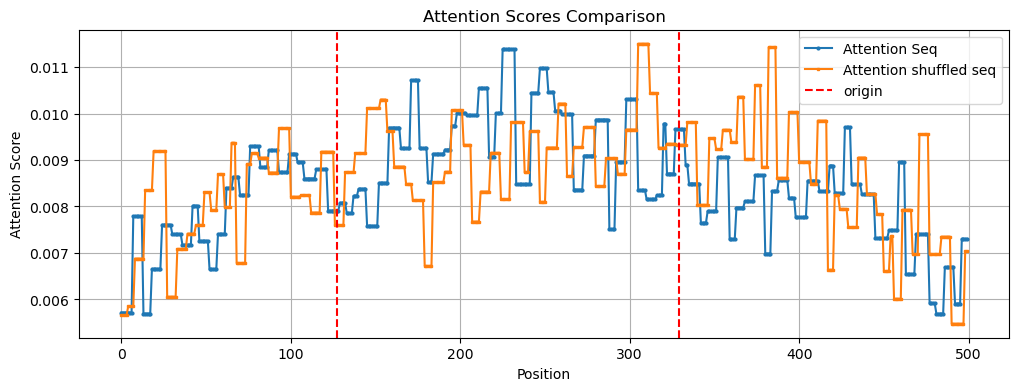

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     15
start                                               873960
end                                                 874459
seq      TGATTACGTTCATCGAATTTTACATGACAGAAAAGAACTTGTTAAT...
label                                                    1
pred                                                     1
Name: 95, dtype: object
     chr   start     end         name  length
300   15  874190  874434  1526,00 ARS     245
original:  0.9945727
shuffled:  0.9945156


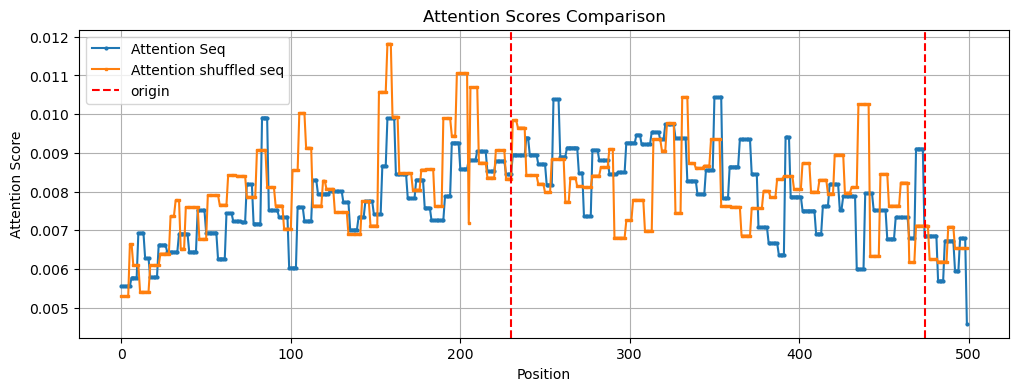

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      1
start                                               175911
end                                                 176410
seq      AACGATATTCGATAATGCGCCAAGCCTTTATAAGGAACTCAAAATA...
label                                                    1
pred                                                     1
Name: 97, dtype: object
   chr   start     end        name  length
4    1  176154  176402  110,00 ARS     249
original:  0.9946025
shuffled:  0.9945393


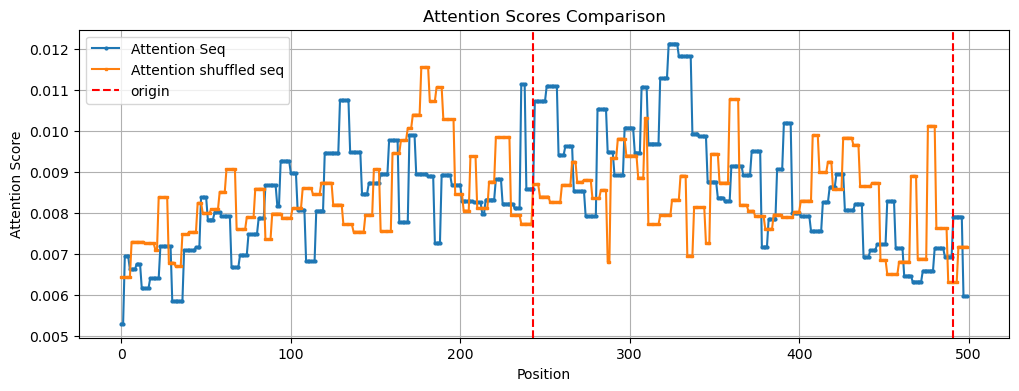

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      4
start                                               639744
end                                                 640243
seq      GAGACCATGTTCTGCAACATTTAAATAAAAAAATTCCATGCACTCA...
label                                                    1
pred                                                     1
Name: 100, dtype: object
    chr   start     end        name  length
57    4  639859  640108  421,00 ARS     250
original:  0.9945852
shuffled:  0.9945496


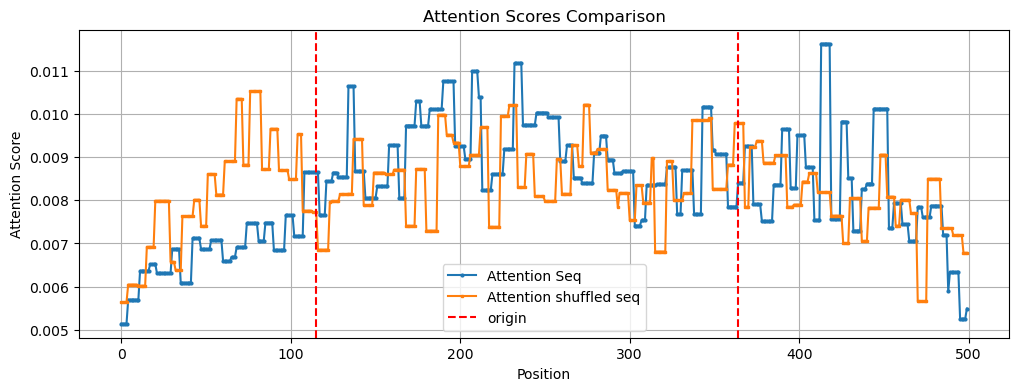

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     15
start                                                35529
end                                                  36028
seq      TGCAAACTTTGACGAGAATGTACTGCTCATTATTTTTCGTAAACTG...
label                                                    1
pred                                                     1
Name: 103, dtype: object
     chr  start    end       name  length
279   15  35667  35903  ARS1506.5     237
original:  0.9945862
shuffled:  0.99454284


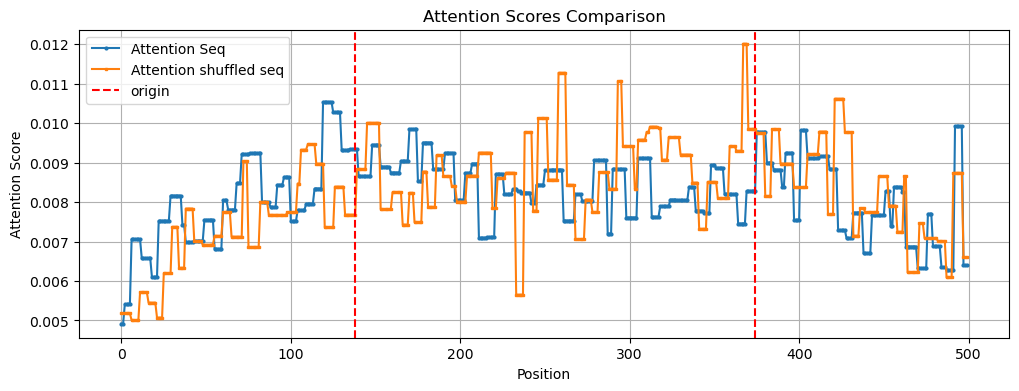

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     13
start                                               535438
end                                                 535937
seq      CGTGAAACCAAACATAGTTTAACTCCCTATAGCTCCATTTGATAAG...
label                                                    1
pred                                                     1
Name: 105, dtype: object
     chr   start     end         name  length
245   13  535595  535843  1320,00 ARS     249
original:  0.9945787
shuffled:  0.99453837


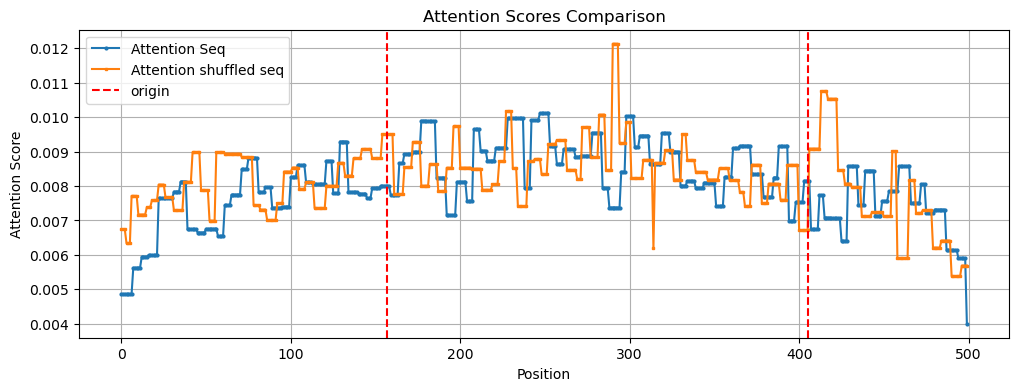

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      8
start                                               535393
end                                                 535892
seq      TACTCATTGGTGTGTGTCAAAAACAGTACGTTTATTATCTGGACAG...
label                                                    1
pred                                                     1
Name: 110, dtype: object
     chr   start     end      name  length
149    8  535403  535836  ARS823.5     434
original:  0.9945651
shuffled:  0.99450475


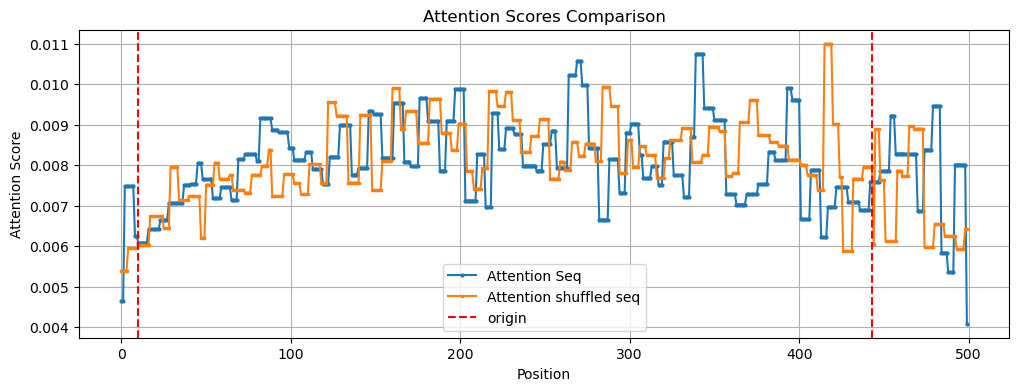

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     16
start                                               633839
end                                                 634338
seq      TTACTTTCATGGAACACTTAGTAAAAATAACTTAGAAAGGTCGTCT...
label                                                    1
pred                                                     1
Name: 112, dtype: object
     chr   start     end         name  length
316   16  633868  634117  1623,00 ARS     250
original:  0.9945648
shuffled:  0.9945497


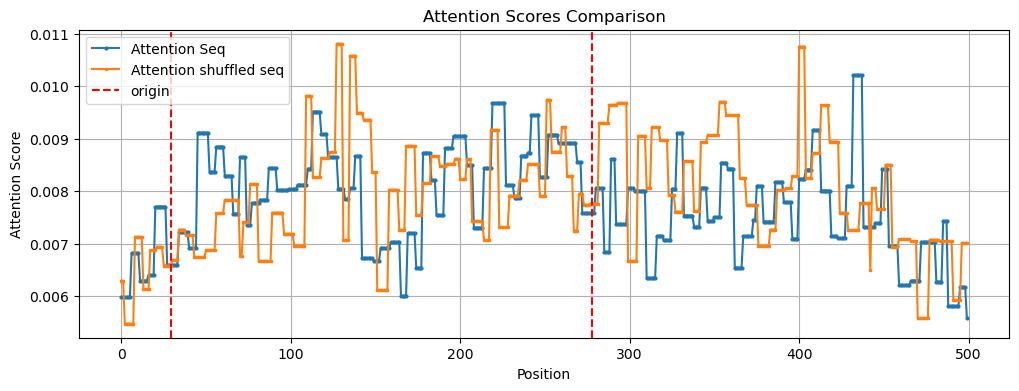

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      4
start                                                15368
end                                                  15867
seq      AAAAAATTAGAGATTCATTGAATCTCTAATTTATTTAAAGTTTATA...
label                                                    1
pred                                                     1
Name: 114, dtype: object
    chr  start    end        name  length
38    4  15492  15739  403,00 ARS     248
original:  0.9945643
shuffled:  0.9945235


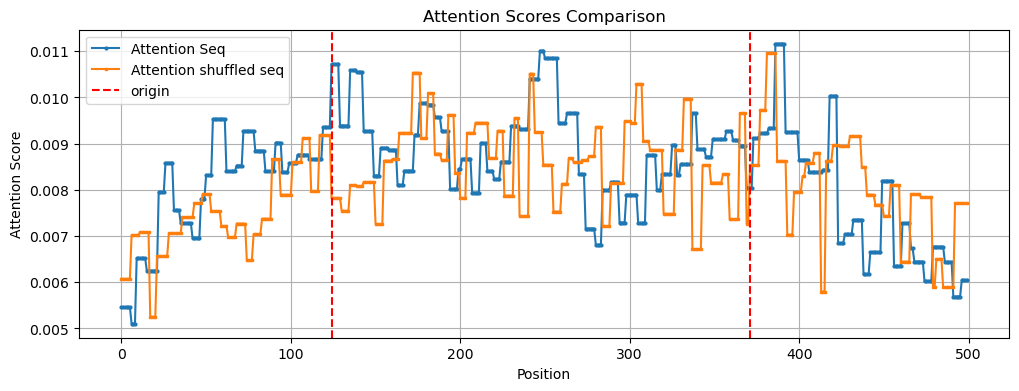

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                     16
start                                               842595
end                                                 843094
seq      TGGCTGAGAGGAATTCTAAGATTTCTAATGTGGAGAGGTATACTCT...
label                                                    1
pred                                                     1
Name: 122, dtype: object
     chr   start     end         name  length
322   16  842646  842894  1628,00 ARS     249
original:  0.9945527
shuffled:  0.9945123


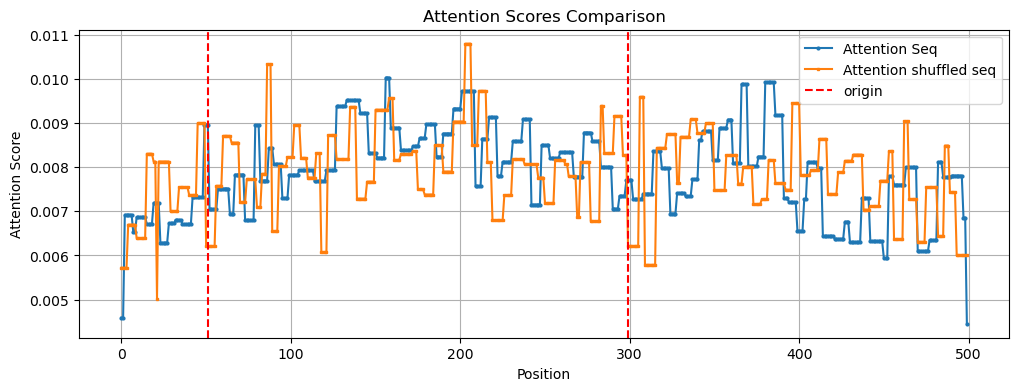

/p/home/jusers/piroozeh1/juwels/.cache/huggingface/modules/transformers_modules/model2/bert_layers.py:128: UserWarning: Unable to import Triton; defaulting MosaicBERT attention implementation to pytorch (this will reduce throughput when using this model).
  warnings.warn(


chr                                                      8
start                                               555958
end                                                 556457
seq      ACATAACTGAATGTTAAAATGGCATCATCAATACAGTATTACTGAT...
label                                                    1
pred                                                     1
Name: 129, dtype: object
     chr   start     end        name  length
150    8  555996  556327  824,00 ARS     332
original:  0.9943997
shuffled:  0.9943764


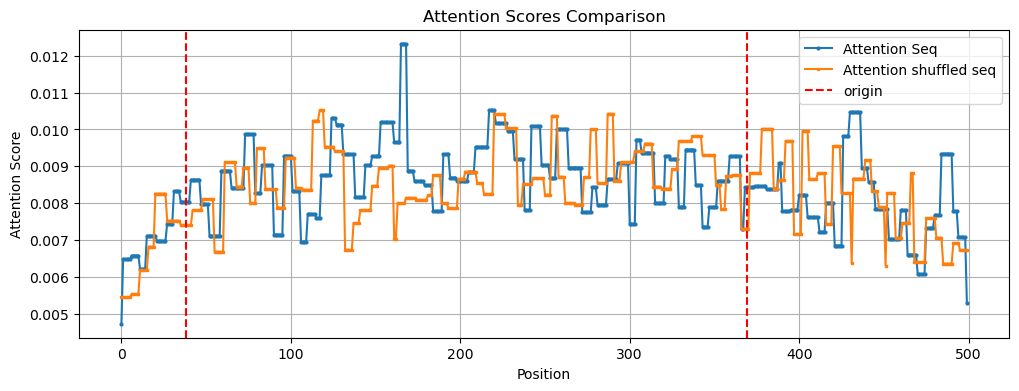

In [10]:
model_path = "/p/project/hai_dnaori/piroozeh1/yeast-origins/data/OriDB_random_neg/train_dev_test_oridb/DNABERT2/model2"
original_origin=pd.read_csv("/p/project1/hai_dnaori/piroozeh1/yeast-origins/data/yeast_oridbLess500.csv")   
for index, row in true_positives.iterrows():
     # if index<10:
    
        prob1, prob2, att1, att2=inference_model( model_path, row["seq"])
        if prob2[0,1] < prob1[0,1]:
            matching_rows = original_origin[(original_origin['chr'] == row['chr']) & (original_origin['start'] >= row['start']) & (original_origin['end'] <= row['end'])]
            print(row)
            print(matching_rows)
            
            origin_start=matching_rows['start'].values[0]
            origin_end=matching_rows['end'].values[0]
            print("original: ", prob1[0,1])
            
            print("shuffled: ", prob2[0,1])
           
            visualize(att1, att2, origin_start, origin_end, row['start']) 
